##**SINGAPORE RETAIL LOCATION INTELLIGENCE**


> Retail market research project using **Python, BeautifulSoup, Pandas and data visualization**




## Business Objective

Collect publicly available retail location data and transform it into structured market intelligence that can support location-based decision making.

## Research Question

- Which regions contain the highest concentration of shopping malls?
- How can web scraping streamline secondary market research?

###Install packages & Import Libraries

In [1]:
!pip install beautifulsoup4 requests pandas matplotlib

In [2]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt

#### Download webpage

In [3]:
url = "https://en.wikipedia.org/wiki/List_of_shopping_malls_in_Singapore"

headers = {
    "User-Agent": "Mozilla/5.0"
}

response = requests.get(url, headers=headers)

print(response.status_code)

200


### Parse HTML - so it becomes searchable

In [4]:
soup = BeautifulSoup(response.text, "html.parser")

### Inspect Headings

In [5]:
headings = soup.find_all("h2")

for h in headings:
    print(h.get_text(strip=True))

Contents
Central
East
North
North-East
West
References


### Extract malls by region.

What this does?

Example HTML

```
<h2>Central</h2>

<ul>
<li>ION Orchard</li>
<li>VivoCity</li>
</ul>
```
> <h2>Central</h2>
> <ul>
> <li>ION Orchard</li>
> <li>VivoCity</li>
> </ul>

become A table like below

In [6]:
regions = ["Central", "East", "North", "North-East", "West"]

mall_data = []

for heading in soup.find_all("h2"):

    title = heading.get_text(strip=True)

    if title not in regions:
        continue

    ul = heading.find_next("ul")

    if ul:
        for li in ul.find_all("li", recursive=False):

            mall_data.append({
                "Region": title,
                "Mall": li.get_text(strip=True)
            })

### Convert to DataFrame

In [7]:
df = pd.DataFrame(mall_data)

df.head()


,Region,Mall
0,Central,313@somerset
1,Central,Alexandra Retail Centre
2,Central,Bugis Junction
3,Central,Bugis+
4,Central,Capitol Piazza


### Create folders inside Colab
Because in colab its not auto created

In [8]:
import os

folders = [
    "data",
    "screenshots"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Folders created.")

Folders created.


In [9]:
df.to_csv("data/singapore_malls_raw.csv", index=False)

## Data cleaning

The dataset was cleaned by removing duplicates, standardising text, checking missing values, and preparing reusable CSV outputs.

In [10]:
df = df.drop_duplicates() #duplicates

df["Mall"] = df["Mall"].str.strip() #extra spaces

df.isnull().sum() #missing values

,0
Region,0
Mall,0


In [11]:
df.to_csv("data/singapore_malls_cleaned.csv", index=False)

## Market Insights

The cleaned dataset was analysed to identify retail concentration patterns across Singapore's planning regions.

In [12]:
region_counts = (
    df["Region"]
    .value_counts()
    .sort_values(ascending=False)
)

print(region_counts)

Region
Central       49
West          26
East          19
North-East    14
North          6
Name: count, dtype: int64


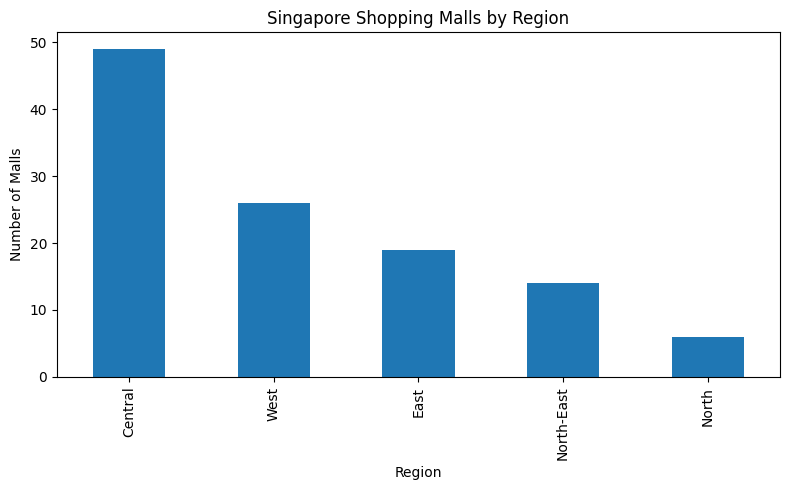

In [13]:
plt.figure(figsize=(8,5))

region_counts.plot(kind="bar")

plt.title("Singapore Shopping Malls by Region")
plt.xlabel("Region")
plt.ylabel("Number of Malls")

plt.tight_layout()

plt.show()

In [14]:
plt.savefig(
    "screenshots/malls_by_region.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

## Key Findings

###Finding 1

Central Singapore has the highest concentration of shopping malls, indicating the strongest retail cluster.

###Finding 2

West and East Singapore contain substantial retail networks, suggesting decentralized commercial activity.

###Finding 3

Regional distribution highlights opportunities for comparing retail density across different planning areas.

In [15]:
from datetime import datetime

today = datetime.today().strftime("%Y-%m-%d")

filename = f"data/malls_snapshot_{today}.csv"

df.to_csv(filename, index=False)

print("Saved:", filename)

Saved: data/malls_snapshot_2026-09-04.csv
